Mean Squared Error: 7.67


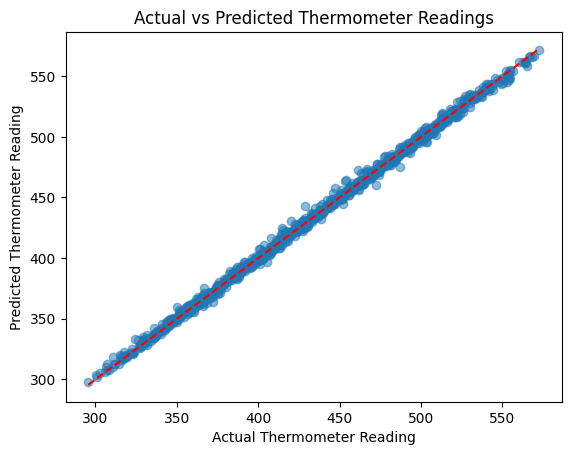

In [6]:
import numpy as np

def velocity(r, R, Umax):
    return Umax * (1 - (r/R)**2)

def temperature(r, R, Tc, Tw, n):
    return Tc + (Tw - Tc) * (r/R)**n

def thermometer_reading(R, Umax, Tc, Tw, n):
    r = np.linspace(0, R, 500)
    u = velocity(r, R, Umax)
    T = temperature(r, R, Tc, Tw, n)

    numerator = np.trapz(u * T * r, r)
    denominator = np.trapz(u * r, r)

    return (numerator / denominator) if denominator != 0 else 0

X = []  # inputs
y = []  # thermometer readings

for _ in range(5000):
    R = np.random.uniform(0.01, 0.1)
    Umax = np.random.uniform(0.5, 5)
    Tc = np.random.uniform(300, 600)
    Tw = np.random.uniform(280, 500)
    n = np.random.uniform(1, 4)

    Tind = thermometer_reading(R, Umax, Tc, Tw, n)

    X.append([R, Umax, Tc, Tw, n])
    y.append(Tind)
    
X = np.array(X)
y = np.array(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Thermometer Reading')
plt.ylabel('Predicted Thermometer Reading')
plt.title('Actual vs Predicted Thermometer Readings')
plt.show()


In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --------------------------------------------------
# 1. Physical parameters
# --------------------------------------------------
R = 0.05          # pipe radius (m)
Umax = 2.0        # centerline velocity (m/s)
Tw = 350.0        # wall temperature (K)
Tc = 400.0        # reference center temperature (K)

T_measured = 340.0  # thermometer reading (K)

# Normalization constants
T_scale = Tc - Tw

# --------------------------------------------------
# 2. Velocity profile
# --------------------------------------------------
def velocity(r):
    return Umax * (1 - (r / R) ** 2)

# --------------------------------------------------
# 3. PINN model (predicts normalized temperature θ)
# --------------------------------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 1)
        )

    def forward(self, r):
        return self.net(r)

model = PINN()

# --------------------------------------------------
# 4. Autograd helper
# --------------------------------------------------
def grad(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

# --------------------------------------------------
# 5. Collocation points (biased toward r = 0)
# --------------------------------------------------
Nr = 300
r = (torch.rand(Nr, 1) ** 2) * R
r.requires_grad = True

r0 = torch.tensor([[0.0]], requires_grad=True)
rR = torch.tensor([[R]], requires_grad=True)

# --------------------------------------------------
# 6. Optimizers
# --------------------------------------------------
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=100,
)

# --------------------------------------------------
# 7. Training: Curriculum Learning
# --------------------------------------------------
epochs_adam = 4000

loss_history = []

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()

    # ---- Network output (normalized temperature) ----
    theta = model(r)
    T = theta * T_scale + Tw

    # ---- PDE residual (stable form) ----
    dT_dr = grad(T, r)
    d2T_dr2 = grad(dT_dr, r)
    residual = d2T_dr2 + (1 / r) * dT_dr
    loss_pde = torch.mean(residual ** 2)

    # ---- Boundary conditions ----
    T0 = model(r0) * T_scale + Tw
    dT_dr_0 = grad(T0, r0)
    loss_center = dT_dr_0.pow(2)

    TR = model(rR) * T_scale + Tw
    loss_wall = (TR - Tw) ** 2

    # ---- Thermometer constraint (use 1D tensors for integration) ----
    r_flat = r.squeeze(-1)
    u_flat = velocity(r).squeeze(-1)
    T_flat = T.squeeze(-1)
    numerator = torch.trapz(u_flat * T_flat * r_flat, r_flat)
    denominator = torch.trapz(u_flat * r_flat, r_flat)
    T_indicated = numerator / denominator
    loss_sensor = (T_indicated - T_measured) ** 2

    # ---- Curriculum loss scheduling ----
    if epoch < 1000:
        loss = 10 * loss_center + 10 * loss_wall
    elif epoch < 2500:
        loss = loss_pde + 10 * loss_center + 10 * loss_wall
    else:
        loss = (
            loss_pde
            + 10 * loss_center
            + 10 * loss_wall
            + 0.01 * loss_sensor
        )

    loss.backward()
    optimizer_adam.step()
    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4e}")

# --------------------------------------------------
# 8. LBFGS refinement
# --------------------------------------------------
def closure():
    optimizer_lbfgs.zero_grad()

    theta = model(r)
    T = theta * T_scale + Tw

    dT_dr = grad(T, r)
    d2T_dr2 = grad(dT_dr, r)
    residual = d2T_dr2 + (1 / r) * dT_dr
    loss_pde = torch.mean(residual ** 2)

    T0 = model(r0) * T_scale + Tw
    dT_dr_0 = grad(T0, r0)
    loss_center = dT_dr_0.pow(2)

    TR = model(rR) * T_scale + Tw
    loss_wall = (TR - Tw) ** 2

    # Thermometer constraint (use 1D tensors for integration)
    r_flat = r.squeeze(-1)
    u_flat = velocity(r).squeeze(-1)
    T_flat = T.squeeze(-1)
    numerator = torch.trapz(u_flat * T_flat * r_flat, r_flat)
    denominator = torch.trapz(u_flat * r_flat, r_flat)
    T_indicated = numerator / denominator
    loss_sensor = (T_indicated - T_measured) ** 2

    loss = (
        loss_pde
        + 10 * loss_center
        + 10 * loss_wall
        + 0.01 * loss_sensor
    )

    loss.backward()
    return loss

optimizer_lbfgs.step(closure)



Epoch 0, Loss = 1.0771e+03
Epoch 500, Loss = 9.5173e-13
Epoch 1000, Loss = 1.3366e+00
Epoch 1500, Loss = 8.3983e+00
Epoch 2000, Loss = 5.2688e+00
Epoch 2500, Loss = 6.2691e+00
Epoch 3000, Loss = 6.2680e+00
Epoch 3500, Loss = 6.2675e+00


tensor([[6.2679]], grad_fn=<AddBackward0>)

In [8]:
# --------------------------------------------------
# 9. Post-processing
# --------------------------------------------------

r_plot = torch.linspace(0, R, 200).view(-1, 1)

with torch.no_grad():
    theta_plot = model(r_plot)
    T_plot = theta_plot * T_scale + Tw

# Compute final thermometer prediction
with torch.no_grad():
    theta_final = model(r)
    T_final = theta_final * T_scale + Tw

    r_flat = r.squeeze(-1)
    u_final_flat = velocity(r).squeeze(-1)
    T_final_flat = T_final.squeeze(-1)

    numerator_final = torch.trapz(u_final_flat * T_final_flat * r_flat, r_flat)
    denominator_final = torch.trapz(u_final_flat * r_flat, r_flat)

    T_indicated = numerator_final / denominator_final

print("\nFinal thermometer prediction:", T_indicated.item())




Final thermometer prediction: 349.9913330078125


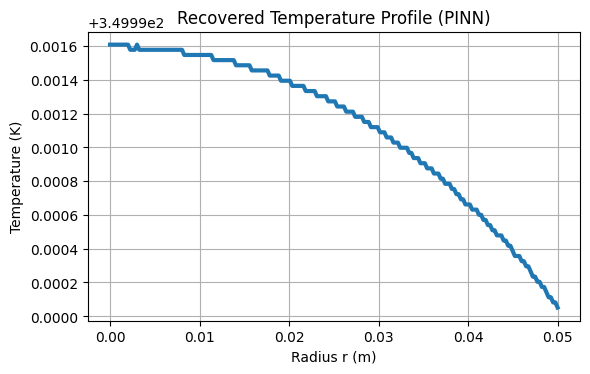

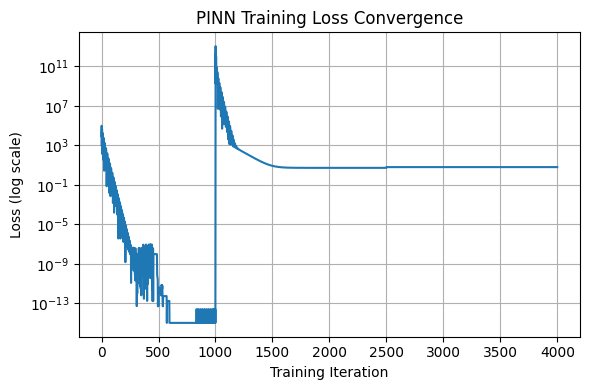

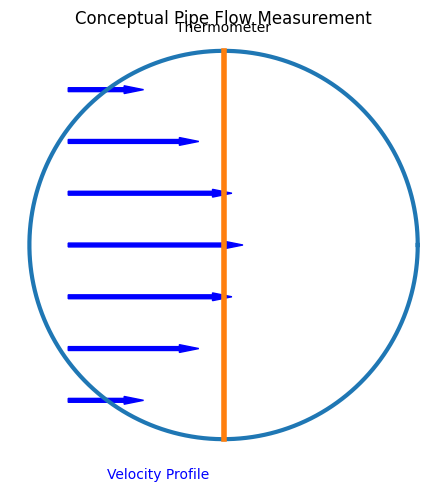

In [9]:
# --------------------------------------------------
# Temperature profile plot
# --------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(r_plot.numpy(), T_plot.numpy(), linewidth=3)
plt.xlabel("Radius r (m)")
plt.ylabel("Temperature (K)")
plt.title("Recovered Temperature Profile (PINN)")
plt.grid(True)
plt.tight_layout()

plt.savefig("temperature_profile.png", dpi=300)
plt.show()

# --------------------------------------------------
# Training loss curve
# --------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Training Iteration")
plt.ylabel("Loss (log scale)")
plt.title("PINN Training Loss Convergence")
plt.grid(True)

plt.tight_layout()
plt.savefig("training_loss.png", dpi=300)
plt.show()

# --------------------------------------------------
# Pipe concept diagram
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(5,5))

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(R*np.cos(theta), R*np.sin(theta), linewidth=3)

# velocity arrows
for y in np.linspace(-R*0.8, R*0.8, 7):
    length = (1 - (y/R)**2) * 0.04
    ax.arrow(-0.04, y, length, 0,
             head_width=0.002,
             head_length=0.005,
             color='blue')

# thermometer probe
ax.plot([0,0],[-R,R],linewidth=4)

ax.text(0, R+0.005, "Thermometer", ha='center')
ax.text(-0.03, -R-0.01, "Velocity Profile", color='blue')

ax.set_aspect('equal')
ax.axis('off')
plt.title("Conceptual Pipe Flow Measurement")

plt.tight_layout()
plt.savefig("pipe_concept.png", dpi=300)
plt.show()



In [10]:
# --------------------------------------------------
# Save trained model
# --------------------------------------------------

import pickle

model_data = {
    "model_state_dict": model.state_dict(),
    "R": R,
    "Tw": Tw,
    "Tc": Tc,
    "T_scale": T_scale,
    "Umax": Umax
}

with open("pinn_pipe_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("\nModel saved as pinn_pipe_model.pkl")


Model saved as pinn_pipe_model.pkl
